# PPR Fantasy Points Regression Using Sentiment Indices

While much of our analysis has focused on determining correlations between sentiment indices and performance metrics, it is unclear if sentiment indices can predict the next week's performance. This is an investigation into the above hypothesis that sentiment indices are useful for predicting athletic performance (in this case, PPR fantasy points)

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold, cross_val_score, PredefinedSplit
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

## EDA

In [6]:
# Read in data
twitter_df = pd.read_csv('sentiment_indices/twitter_local_index_no_keenan.csv')
global_df = pd.read_csv('sentiment_indices/global_index_no_keenan.csv')
perf_df = pd.read_csv('data/nfl_sentiment_2025_cleaned.csv')

# Filter to appropriate columns
perf_df = perf_df[['player_name', 'player_position', 'team_abbreviation', 'game_week', 'fantasy_points_ppr', 'opp_defense_dvoa']]

# Join sentiment data frames together
sent_df = pd.merge(twitter_df, global_df, left_on=['subject', 'game_id'], right_on=['player', 'week'])
sent_df = sent_df[['player', 'week', 'local_index', 'global_index']]

# Make corrections to data types/player names as necessary
sent_df['player'] = sent_df['player'].replace({'AJ Brown': 'A.J. Brown',
                                               'JaMarr Chase': 'Ja\'Marr Chase',
                                               'Greg Rousseau': 'Gregory Rousseau',
                                               'Michael Pittman Jr': 'Michael Pittman',
                                               'Antoine Winfield Jr': 'Antoine Winfield Jr.'})
sent_df['week'] = sent_df.apply(
    lambda x: int(x['week'][1:]), axis=1
)

# Join sentiment and performance indices together
df = pd.merge(perf_df, sent_df, left_on=['player_name', 'game_week'], right_on=['player', 'week'])
df = df[['player', 'fantasy_points_ppr', 'player_position', 'team_abbreviation', 'week', 'opp_defense_dvoa', 'local_index', 'global_index']]
df = df.rename(columns={'local_index': 'twitter_index'})
df.head()

,player,fantasy_points_ppr,player_position,team_abbreviation,week,opp_defense_dvoa,twitter_index,global_index
0,Dak Prescott,7.82,QB,DAL,1,-9.9,45.722312,46.622208
1,Saquon Barkley,18.40,RB,PHI,1,22.5,64.864458,57.024445
2,A.J. Brown,1.80,WR,PHI,1,22.5,39.802578,44.493505
3,CeeDee Lamb,18.00,WR,DAL,1,-9.9,50.161475,48.841789
4,Zack Baun,0.00,ILB,PHI,1,22.5,65.895185,57.539808


In [8]:
off_df = df[df['player_position'].isin(['QB', 'RB', 'WR', 'TE'])]
off_df['prev_fantasy_pts'] = off_df.groupby('player')['fantasy_points_ppr'].shift(1)
off_df['prev_twitter_index'] = off_df.groupby('player')['twitter_index'].shift(1)
off_df['prev_global_index'] = off_df.groupby('player')['global_index'].shift(1)
off_df = off_df.drop(columns={'twitter_index', 'global_index'})
off_df = off_df.dropna()

/tmp/ipykernel_75355/2844722803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  off_df['prev_fantasy_pts'] = off_df.groupby('player')['fantasy_points_ppr'].shift(1)
/tmp/ipykernel_75355/2844722803.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  off_df['prev_twitter_index'] = off_df.groupby('player')['twitter_index'].shift(1)
/tmp/ipykernel_75355/2844722803.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

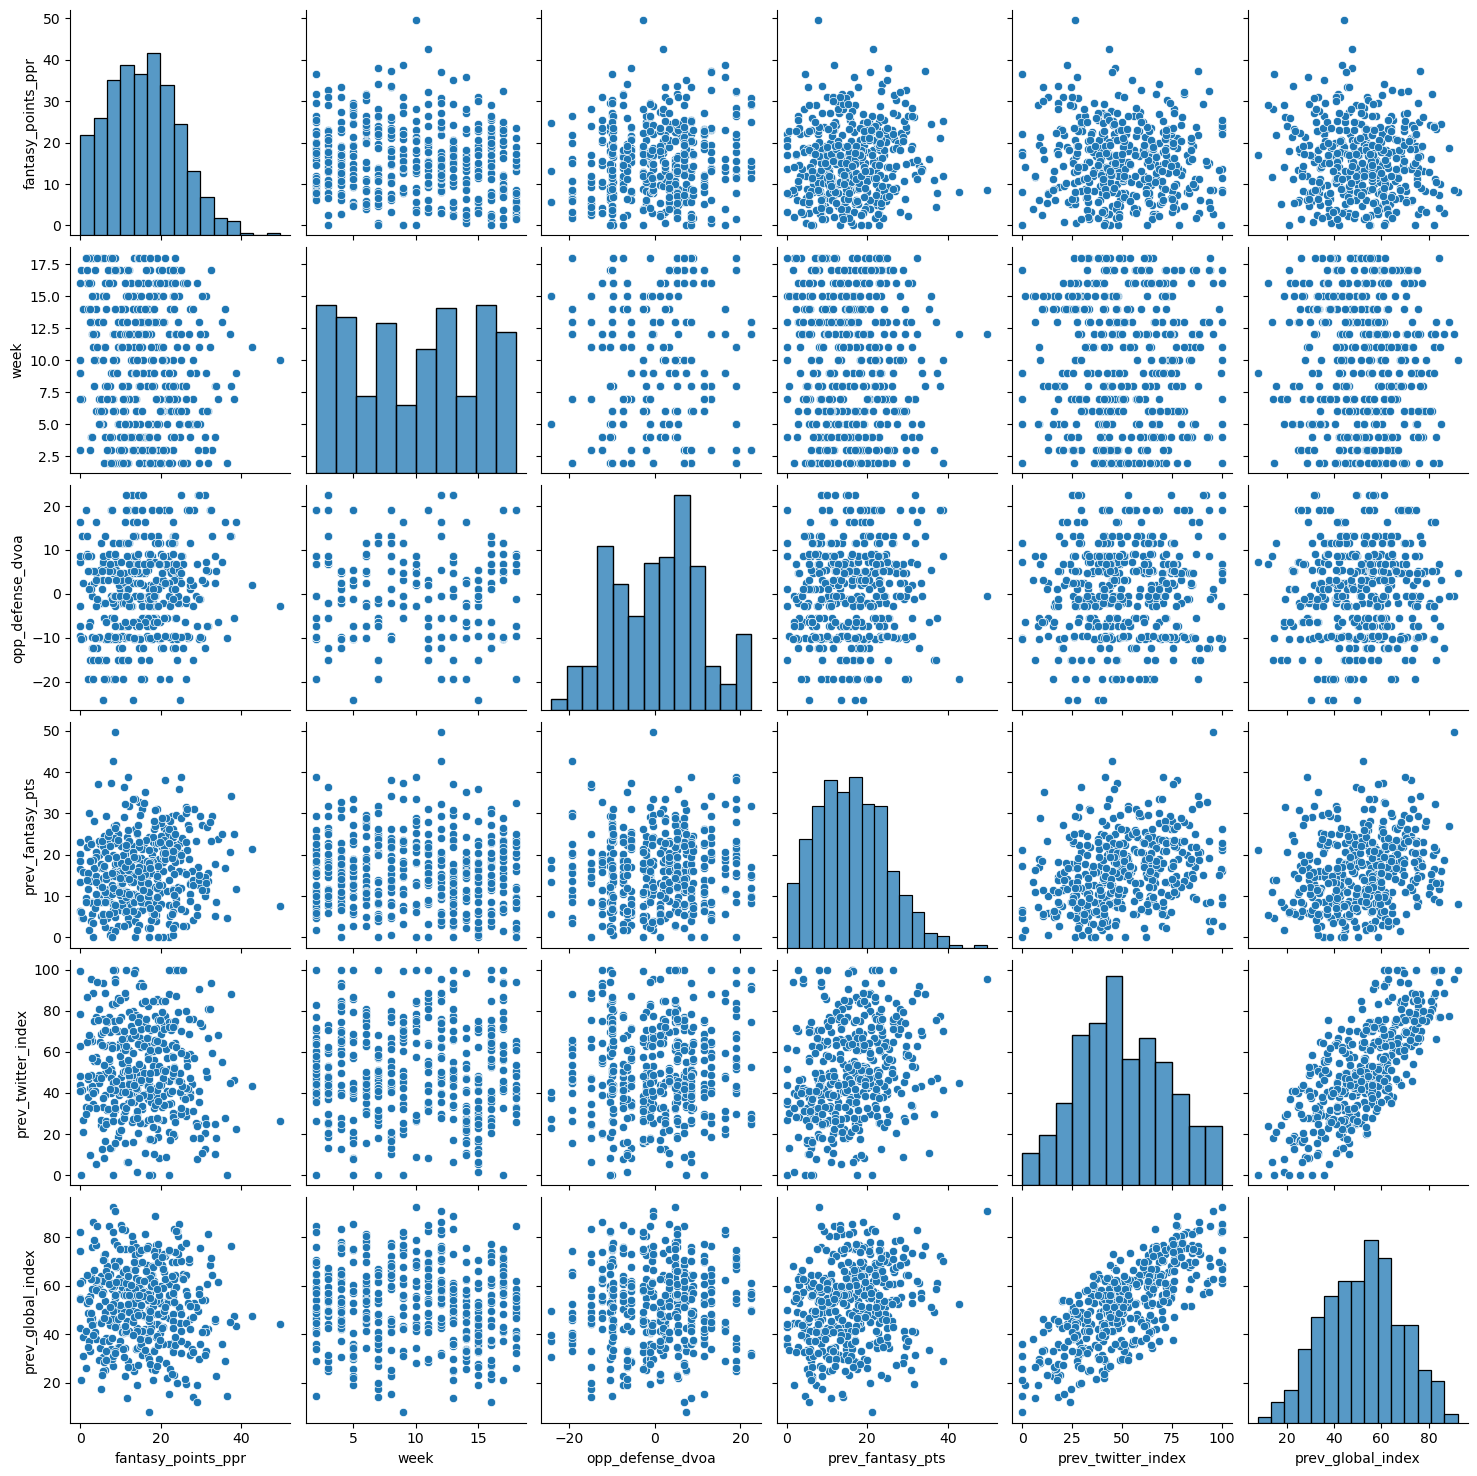

In [9]:
sns.pairplot(off_df.drop('player', axis=1))
plt.show()

No evidence to make and transformations or use relationships other than linear for the first go around

No collinearity with other predictors either

# One-Hot Encode Position

In [10]:
off_df = pd.concat([off_df, pd.get_dummies(off_df['player_position'])], axis=1)
off_df.head()

,player,fantasy_points_ppr,player_position,team_abbreviation,week,opp_defense_dvoa,prev_fantasy_pts,prev_twitter_index,prev_global_index,QB,RB,TE,WR
43,Stefon Diggs,7.20,WR,NE,2,6.8,11.70,77.201111,84.467735,False,False,False,True
44,Dak Prescott,22.14,QB,DAL,2,8.5,7.82,45.722312,46.622208,True,False,False,False
47,Sam Darnold,15.80,QB,SEA,2,-5.5,7.40,47.351028,57.585837,True,False,False,False
48,Josh Allen,11.82,QB,BUF,2,19.0,38.76,41.552583,28.803867,True,False,False,False
49,DJ Moore,9.60,WR,CHI,2,-7.4,10.60,43.822793,50.196948,False,False,False,True


# Baseline Model

In [11]:
off_df = off_df.reset_index(drop=True)
groups = off_df['player']

gkf = GroupKFold(n_splits=5)

base_X = off_df[['prev_fantasy_pts', 'opp_defense_dvoa', 'RB', 'TE', 'WR']]
y = off_df[['fantasy_points_ppr']]

for fold, (train_idx, val_idx) in enumerate(gkf.split(base_X, y, groups)):
    off_df.loc[val_idx, 'fold'] = fold

ps = PredefinedSplit(test_fold=off_df['fold'])

base_model = LinearRegression()

## Model Diagnostics

In [12]:
# 1. Fit scikit-learn model and get residuals
base_model.fit(base_X, y)
residuals = y - base_model.predict(base_X)
std_resids = (residuals - np.mean(residuals)) / np.std(residuals)

/home/rjy2/anaconda3/envs/sentiment/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


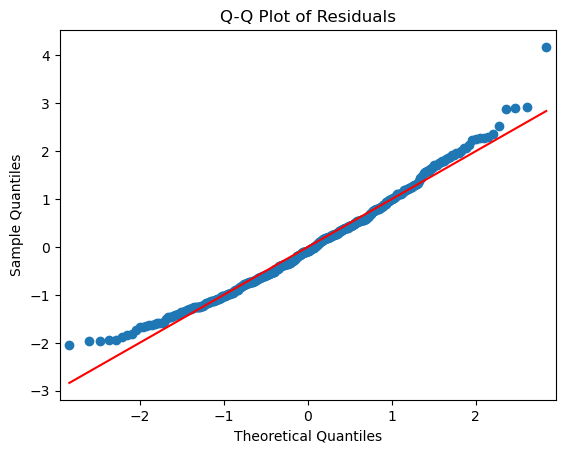

In [13]:
# 2. Check Normality of Residuals with Q-Q plot
sm.qqplot(std_resids['fantasy_points_ppr'], line='s') # Use statsmodels for Q-Q plot
plt.title("Q-Q Plot of Residuals")
plt.show()

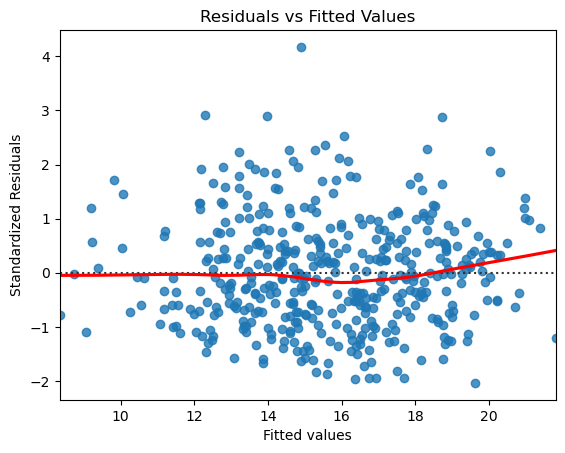

In [14]:
# 3. Check Homoscedasticity/Linearity with Residuals vs. Fitted plot
sns.residplot(x=base_model.predict(base_X), y=std_resids, lowess=True, line_kws={'color':'red'}) # Use seaborn residplot
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Standardized Residuals")
plt.show()

## Cross-Validation

In [15]:
base_scores = cross_val_score(base_model, base_X, y, cv=ps, scoring="neg_root_mean_squared_error")

# Convert negative MSE scores to positive values for easier interpretation as "error"
base_rmse_scores = -base_scores

base_cv_rmse = np.mean(base_rmse_scores)
base_cv_rmse_sd = np.std(base_rmse_scores) / np.sqrt(5)

# Model with Twitter Index

In [16]:
twitter_X = off_df[['prev_twitter_index', 'prev_fantasy_pts', 'opp_defense_dvoa', 'RB', 'TE', 'WR']]
twitter_model = LinearRegression()

## Model Diagnostics

In [17]:
twitter_model.fit(twitter_X, y)
twitter_residuals = y - twitter_model.predict(twitter_X)
twitter_std_resids = (twitter_residuals - np.mean(twitter_residuals)) / np.std(twitter_residuals)

/home/rjy2/anaconda3/envs/sentiment/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


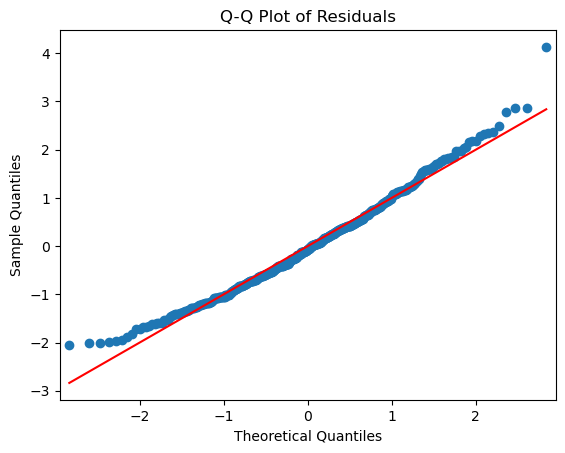

In [18]:
sm.qqplot(twitter_std_resids['fantasy_points_ppr'], line='s') # Use statsmodels for Q-Q plot
plt.title("Q-Q Plot of Residuals")
plt.show()

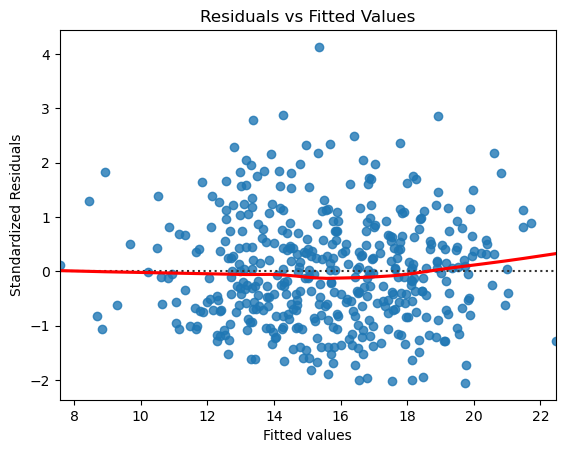

In [19]:
sns.residplot(x=twitter_model.predict(twitter_X), y=twitter_std_resids, lowess=True, line_kws={'color':'red'}) # Use seaborn residplot
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Standardized Residuals")
plt.show()

## Cross-Validation

In [20]:
twitter_scores = cross_val_score(twitter_model, twitter_X, y, cv=ps, scoring="neg_root_mean_squared_error")

# Convert negative MSE scores to positive values for easier interpretation as "error"
twitter_rmse_scores = -twitter_scores

twitter_cv_rmse = np.mean(twitter_rmse_scores)
twitter_cv_rmse_sd = np.std(twitter_rmse_scores) / np.sqrt(5)

# Model with Global Index

In [21]:
global_X = off_df[['prev_global_index', 'prev_fantasy_pts', 'opp_defense_dvoa', 'RB', 'TE', 'WR']]
global_model = LinearRegression()

## Model Diagnostics

In [22]:
global_model.fit(global_X, y)
global_residuals = y - global_model.predict(global_X)
global_std_resids = (global_residuals - np.mean(global_residuals)) / np.std(global_residuals)

/home/rjy2/anaconda3/envs/sentiment/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


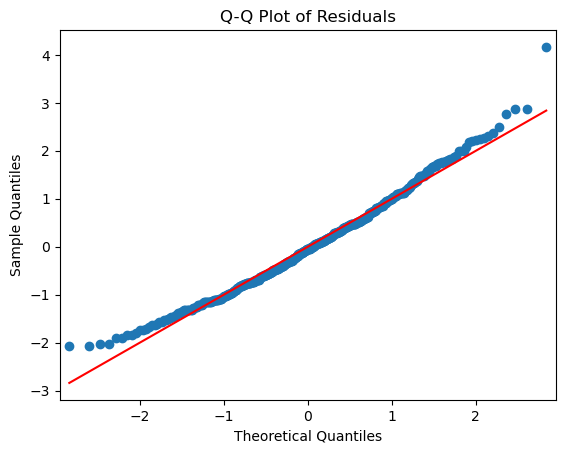

In [23]:
sm.qqplot(global_std_resids['fantasy_points_ppr'], line='s') # Use statsmodels for Q-Q plot
plt.title("Q-Q Plot of Residuals")
plt.show()

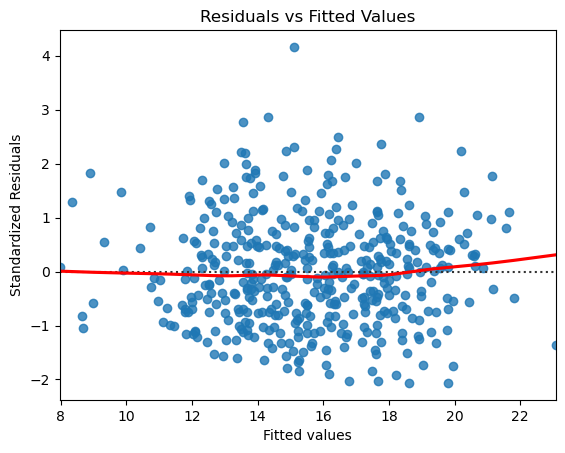

In [24]:
sns.residplot(x=global_model.predict(global_X), y=global_std_resids, lowess=True, line_kws={'color':'red'}) # Use seaborn residplot
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Standardized Residuals")
plt.show()

## Cross-Validation

In [25]:
global_scores = cross_val_score(global_model, global_X, y, cv=ps, scoring="neg_root_mean_squared_error")

# Convert negative MSE scores to positive values for easier interpretation as "error"
global_rmse_scores = -global_scores

global_cv_rmse = np.mean(global_rmse_scores)
global_cv_rmse_sd = np.std(global_rmse_scores) / np.sqrt(5)

## Comparison

In [26]:
cv_rmses = pd.DataFrame({
    'Model': ['Base', 'Twitter', 'Global'],
    'Lower Bound': [base_cv_rmse - base_cv_rmse_sd, twitter_cv_rmse - twitter_cv_rmse_sd, global_cv_rmse - global_cv_rmse_sd],
    'CV RMSE': [base_cv_rmse, twitter_cv_rmse, global_cv_rmse],
    'Upper Bound': [base_cv_rmse + base_cv_rmse_sd, twitter_cv_rmse + twitter_cv_rmse_sd, global_cv_rmse + global_cv_rmse_sd]
})
cv_rmses

,Model,Lower Bound,CV RMSE,Upper Bound
0,Base,8.074782,8.472812,8.870841
1,Twitter,8.078210,8.462076,8.845942
2,Global,8.044451,8.442542,8.840632


## Twitter Partial F-Test

In [27]:
# 1. Fit models: Full (with education) vs Reduced (without education)
full_model = smf.ols('fantasy_points_ppr ~ prev_twitter_index + prev_fantasy_pts + opp_defense_dvoa + C(player_position)', data=off_df).fit()
reduced_model = smf.ols('fantasy_points_ppr ~ prev_fantasy_pts + opp_defense_dvoa + C(player_position)', data=off_df).fit()

# 2. Perform F-test
print(anova_lm(reduced_model, full_model))

   df_resid           ssr  df_diff    ss_diff         F    Pr(>F)
0     433.0  30313.393189      0.0        NaN       NaN       NaN
1     432.0  30175.210440      1.0  138.18275  1.978278  0.160291


So, the twitter local index does not Granger-cause fantasy points

## Global Index Partial F-Test

In [28]:
# 1. Fit models: Full (with sentiment) vs Reduced (without sentiment)
full_model = smf.ols('fantasy_points_ppr ~ prev_global_index + prev_fantasy_pts + opp_defense_dvoa + C(player_position)', data=off_df).fit()
reduced_model = smf.ols('fantasy_points_ppr ~ prev_fantasy_pts + opp_defense_dvoa + C(player_position)', data=off_df).fit()

# 2. Perform F-test
print(anova_lm(reduced_model, full_model))

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0     433.0  30313.393189      0.0         NaN       NaN       NaN
1     432.0  30141.566353      1.0  171.826836  2.462685  0.117311


So, the global index does Granger-cause fantasy points

### Coefficient Interpretation

In [29]:
full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     fantasy_points_ppr   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     7.362
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           1.64e-07
Time:                        14:31:35   Log-Likelihood:                -1551.2
No. Observations:                 439   AIC:                             3116.
Df Residuals:                     432   BIC:                             3145.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   19.0030      1.563     12.155      0.000      15.930      22.076
C(player_position)[T.RB]    -2.3846      1.129     -2.111      0.035      -4.605      -0.165
C(player_position)[T.TE]    -7.1386      1.857     -3.845      0.000     -10.788      -3.489
C(player_position)[T.WR]    -3.9253      0.965     -4.066      0.000      -5.823      -2.028
prev_global_index           -0.0396      0.025     -1.569      0.117      -0.089       0.010
prev_fantasy_pts             0.0730      0.050      1.470      0.142      -0.025       0.171
opp_defense_dvoa             0.1259      0.040      3.169      0.002       0.048       0.204
==============================================================================
Omnibus:                       17.360   Durbin-Watson:                   1.943
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.307
Skew:                           0.485   Prob(JB):                     0.000106
Kurtosis:                       3.242   Cond. No.                         293.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

For a 1 point increase in the previous week's global sentiment index, on average the player's PPR fantasy points will decrease by 0.04 points

## Testing Team Level Differences

Motivated by the player deep dives, in which we saw two Eagles players (Jalen Hurts and AJ Brown) have stronger correlations between their sentiment and athletic performance. In the following code blocks we test if there is a different relationship between sentiment and atheltic performance depending on which team the player plays for.

### Partial F-Test with Twitter

In [30]:
team_full_model = smf.ols('fantasy_points_ppr ~ prev_twitter_index + prev_twitter_index * C(team_abbreviation) + prev_fantasy_pts + opp_defense_dvoa + C(player_position) + C(team_abbreviation)', data=off_df).fit()
team_reduced_model = smf.ols('fantasy_points_ppr ~ prev_fantasy_pts + opp_defense_dvoa + C(player_position) + C(team_abbreviation)', data=off_df).fit()

# 2. Perform F-test
print(anova_lm(team_reduced_model, team_full_model))

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0     424.0  29110.125548      0.0         NaN       NaN       NaN
1     414.0  28507.674715     10.0  602.450833  0.874904  0.556831


### Partial F-Test with Global

In [31]:
team_full_model = smf.ols('fantasy_points_ppr ~ prev_global_index + prev_global_index * C(team_abbreviation) + prev_fantasy_pts + opp_defense_dvoa + C(player_position) + C(team_abbreviation)', data=off_df).fit()
team_reduced_model = smf.ols('fantasy_points_ppr ~ prev_global_index + prev_fantasy_pts + opp_defense_dvoa + C(player_position) + C(team_abbreviation)', data=off_df).fit()

# 2. Perform F-test
print(anova_lm(team_reduced_model, team_full_model))

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0     423.0  29048.321365      0.0         NaN       NaN       NaN
1     414.0  28667.010964      9.0  381.310401  0.611863  0.787157


In [32]:
team_full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     fantasy_points_ppr   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     2.742
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           2.66e-05
Time:                        14:31:55   Log-Likelihood:                -1540.2
No. Observations:                 439   AIC:                             3130.
Df Residuals:                     414   BIC:                             3233.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                        21.3421      4.650      4.589      0.000      12.201      30.484
C(team_abbreviation)[T.CHI]                      -4.3111      6.790     -0.635      0.526     -17.659       9.037
C(team_abbreviation)[T.CIN]                       4.5579      6.002      0.759      0.448      -7.241      16.356
C(team_abbreviation)[T.DAL]                      -3.7530      6.062     -0.619      0.536     -15.669       8.163
C(team_abbreviation)[T.IND]                      -5.9938      6.847     -0.875      0.382     -19.454       7.466
C(team_abbreviation)[T.KC]                       -5.5351      6.229     -0.889      0.375     -17.779       6.709
C(team_abbreviation)[T.NE]                       -2.3889      6.179     -0.387      0.699     -14.535       9.757
C(team_abbreviation)[T.PHI]                       2.1423      5.821      0.368      0.713      -9.300      13.585
C(team_abbreviation)[T.SEA]                      -0.4045      6.594     -0.061      0.951     -13.366      12.557
C(team_abbreviation)[T.TB]                       -6.9609      7.226     -0.963      0.336     -21.164       7.242
C(player_position)[T.RB]                         -3.4108      1.198     -2.848      0.005      -5.765      -1.057
C(player_position)[T.TE]                         -8.6856      2.184     -3.977      0.000     -12.979      -4.393
C(player_position)[T.WR]                         -4.2980      1.008     -4.265      0.000      -6.279      -2.317
prev_global_index                                -0.0259      0.095     -0.273      0.785      -0.213       0.161
prev_global_index:C(team_abbreviation)[T.CHI]     0.0024      0.134      0.018      0.986      -0.261       0.266
prev_global_index:C(team_abbreviation)[T.CIN]    -0.0848      0.125     -0.680      0.497      -0.330       0.160
prev_global_index:C(team_abbreviation)[T.DAL]     0.0528      0.118      0.447      0.655      -0.180       0.285
prev_global_index:C(team_abbreviation)[T.IND]     0.1052      0.130      0.812      0.417      -0.150       0.360
prev_global_index:C(team_abbreviation)[T.KC]      0.0694      0.121      0.573      0.567      -0.169       0.307
prev_global_index:C(team_abbreviation)[T.NE]     -0.0125      0.116     -0.108      0.914      -0.241       0.216
prev_global_index:C(team_abbreviation)[T.PHI]    -0.0803      0.118     -0.683      0.495      -0.312       0.151
prev_global_index:C(team_abbreviation)[T.SEA]    -0.0199      0.125     -0.159      0.874      -0.266       0.226
prev_global_index:C(team_abbreviation)[T.TB]      0.0369      0.144      0.255      0.799      -0.247       0.321
prev_fantasy_pts                                  0.0196      0.052      0.378      0.706      -0.082       0.121
opp_d